# CS 数据加载与快速探索

一键加载帧数据、提取单通道、时间间隔诊断与基础绘图。

后续分段评估见 `glb_cs_segment_breath_analysis.ipynb`；全量滤波算法演示见 `glb_cs_full_pipeline_demo.ipynb`（冻结，不再修改）。


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# 必须先加入 src/，再 import ble_analysis
_cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [_cwd, *_cwd.parents] if (p / "src").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("未找到项目根目录（缺少 src/ 目录）")

_src = project_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from ble_analysis.bootstrap import init_notebook

_env = init_notebook(project_root)
project_root = _env["project_root"]
FIGURES_DIR = _env["FIGURES_DIR"]
PROCESSED_DIR = _env["PROCESSED_DIR"]
REPORTS_DIR = _env["REPORTS_DIR"]


In [7]:
# === 参数（仅改这里）===
filepath = project_root / "sampleData" / "CS_frames_all_20260113_091339.jsonl"
channel = 2


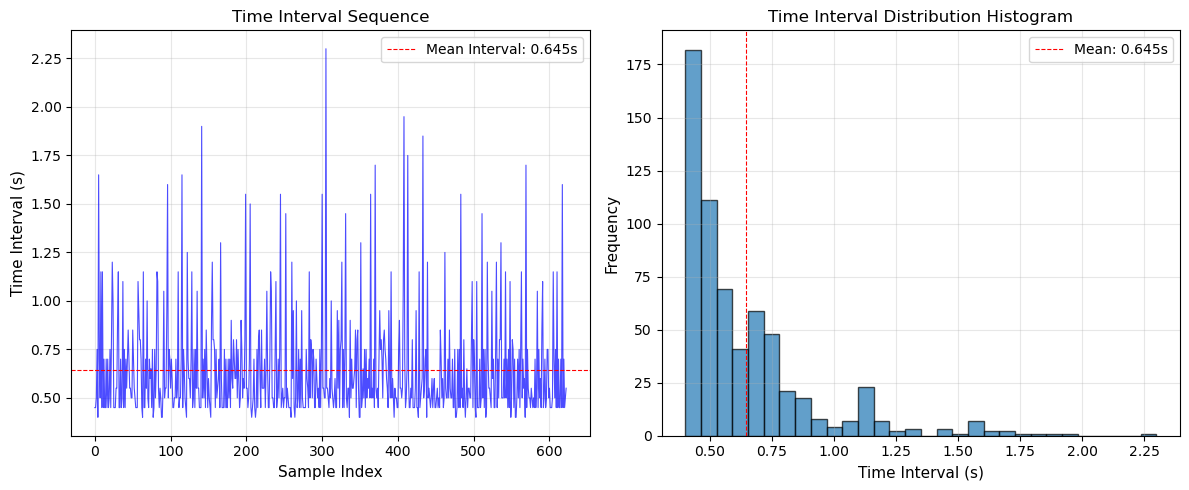

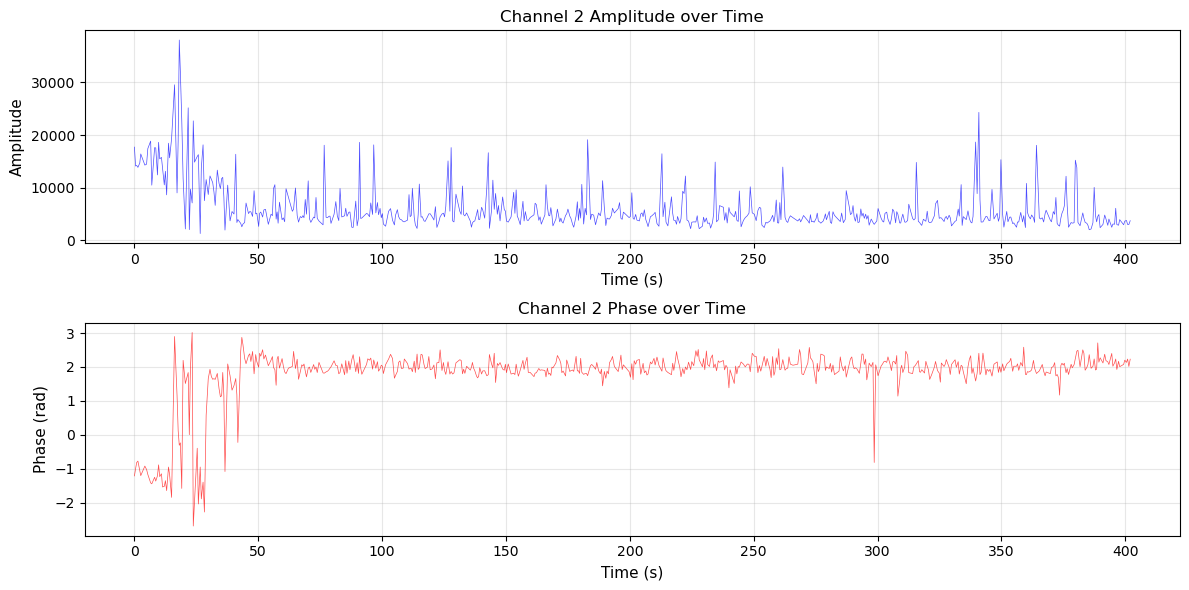

✓ CS_frames_all_20260113_091339.jsonl | v1.0.0 | 733 frames | span 403s | saved 2026-01-13T09:13:39 | ch2: 624 pts | fs≈1.55 Hz | CV=0.422 (不均匀) → figures/channel_2_*.png


In [8]:
from ble_analysis.workflow import run_cs_exploration

result = run_cs_exploration(
    filepath,
    channel,
    figures_dir=FIGURES_DIR,
    verbose=False,
    save_figures=True,
    show_plots=True,
)

data, frames = result["data"], result["frames"]
series = result["series"]
channel = result["channel"]
actual_sampling_rate = result["actual_sampling_rate"]
time_info = result["time_info"]

# 兼容旧变量名
amplitudes = series["amplitudes"]
phases = series["phases"]
local_amplitudes = series["local_amplitudes"]
remote_amplitudes = series["remote_amplitudes"]
timestamps_ms = series["timestamps_ms"]
time_sec = series["time_sec"]


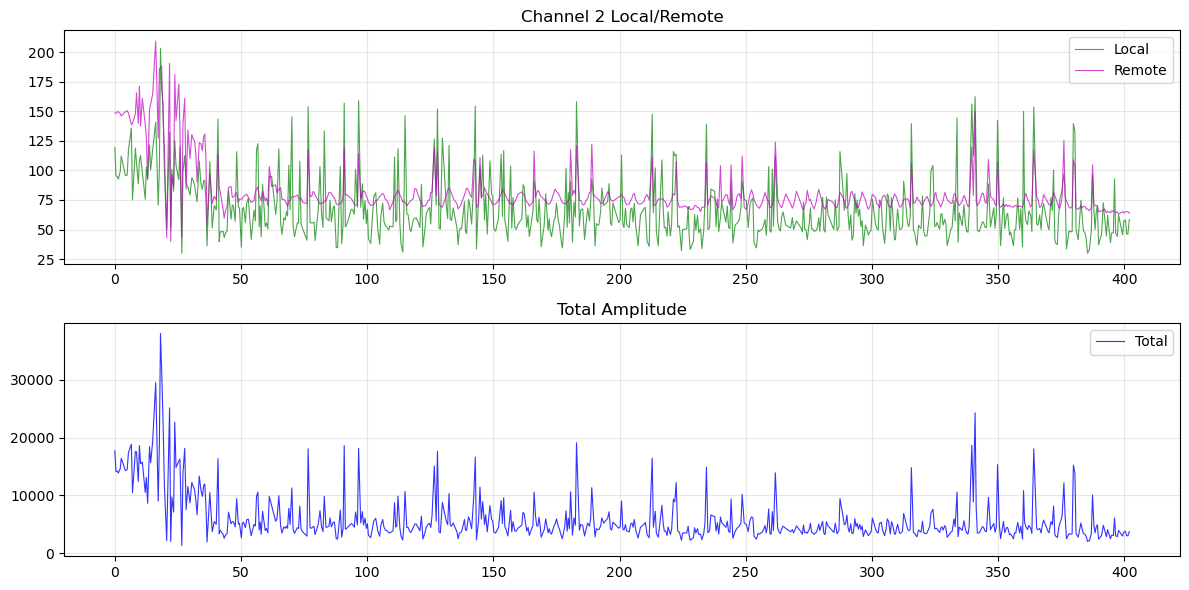

In [9]:
# 可选：Local / Remote 幅值对比
if len(series['amplitudes']) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    axes[0].plot(time_sec, local_amplitudes, 'g-', alpha=0.7, label='Local')
    axes[0].plot(time_sec, remote_amplitudes, 'm-', alpha=0.7, label='Remote')
    axes[0].legend(); axes[0].set_title(f'Channel {channel} Local/Remote')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(time_sec, amplitudes, 'b-', alpha=0.8, label='Total')
    axes[1].legend(); axes[1].set_title('Total Amplitude')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'channel_{channel}_local_remote.png')
    plt.show()
